In [4]:
import torch
import torch.nn as nn
import torch.optim as opt
import matplotlib.pyplot as plt
from torchmetrics import R2Score
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from skorch import NeuralNetRegressor

In [5]:
X, y = make_regression(n_samples=500, n_features=20, n_informative=5, noise=2, random_state=0)

In [6]:
def tensor_train_test_split(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=0)

    tX_train = torch.tensor(X_train).float()
    ty_train = torch.tensor(y_train).float().view(len(y_train), 1)
    tX_test = torch.tensor(X_test).float()
    ty_test = torch.tensor(y_test).float().view(len(y_test), 1)

    return tX_train, tX_test, ty_train, ty_test

## Example: 'hard-coded' regression neural network

In [7]:
tX_train, tX_test, ty_train, ty_test = tensor_train_test_split(X, y)

In [8]:
class HardCodedRegressionNN(nn.Module):
    def __init__(self, n_features: int):
        """ Creates a feed-forward neural network with one hidden layer
            of size 30, a ReLU activation function, and one output layer.
        """
        super(HardCodedRegressionNN, self).__init__()

        self.hidden_layer = nn.Linear(in_features=n_features, out_features=30)
        self.hidden_activation = nn.ReLU()
        self.output_layer = nn.Linear(in_features=30, out_features=1)

    def forward(self, X):
        """ Performs forward propagation. """
        X = X.float()
        X = self.hidden_layer(X)
        X = self.hidden_activation(X)
        X = self.output_layer(X)

        return X

In [9]:
n, p = tX_train.shape
hard_coded_nn = HardCodedRegressionNN(n_features=p)

In [10]:
optimiser = opt.Adam(hard_coded_nn.parameters(), lr=0.01)
loss_function = nn.HuberLoss()
r2_function = R2Score()
n_iterations = 200

training_loss = list()
training_r2 = list()
test_r2 = list()

for _ in range(n_iterations):
    optimiser.zero_grad()
    training_predictions = hard_coded_nn(tX_train)
    test_predictions = hard_coded_nn(tX_test)
    loss = loss_function(training_predictions, ty_train)
    
    training_loss.append(loss.item())
    training_r2.append(r2_function(training_predictions, ty_train).item())
    test_r2.append(r2_function(test_predictions, ty_test).item())

    loss.backward()
    optimiser.step()

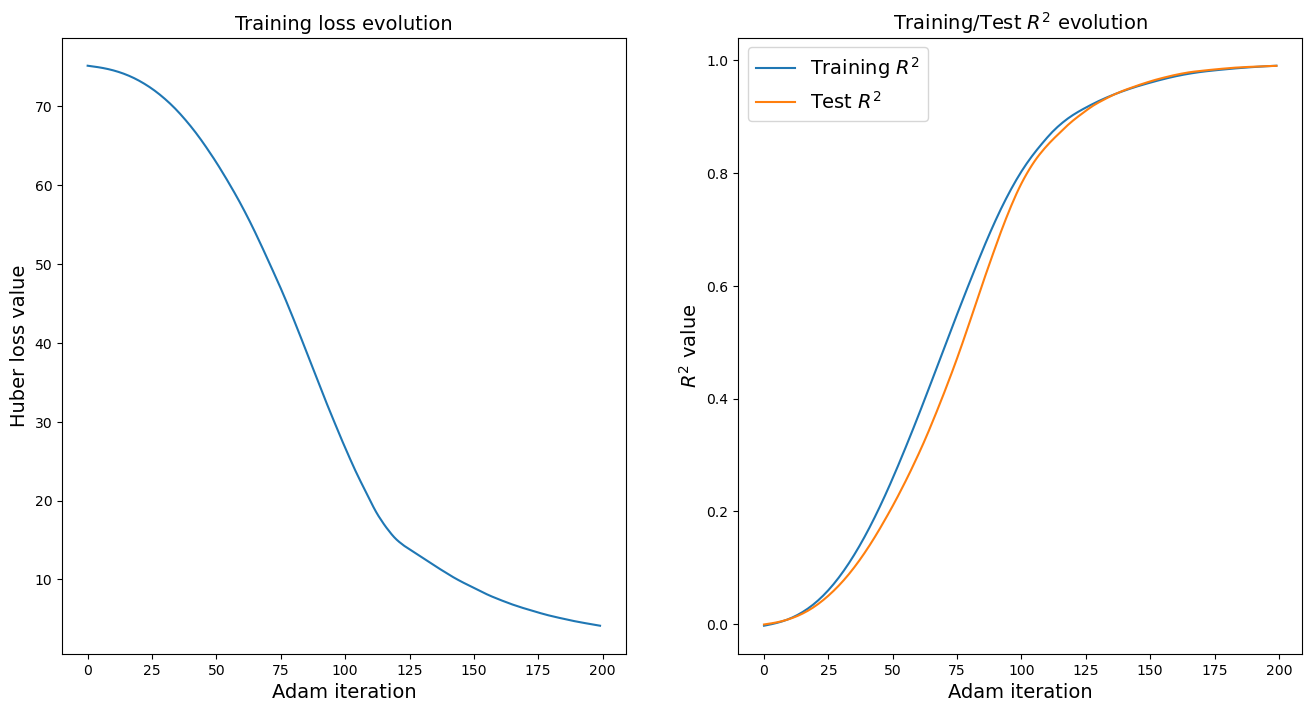

In [13]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(16,8))

ax = axes.flat[0]
ax.plot(range(n_iterations), training_loss)
ax.set_xlabel('Adam iteration', fontsize=14)
ax.set_ylabel('Huber loss value', fontsize=14)
ax.set_title('Training loss evolution', fontsize=14)

ax = axes.flat[1]
ax.plot(range(n_iterations), training_r2, label=r'Training $R^2$')
ax.plot(range(n_iterations), test_r2, label=r'Test $R^2$')
ax.set_xlabel('Adam iteration', fontsize=14)
ax.set_ylabel('$R^2$ value', fontsize=14)
ax.set_title(r'Training/Test $R^2$ evolution', fontsize=14)
ax.legend(fontsize=14);

## Example: regression neural network

This example shows how to use `skorch` to add a FFNN to an `sklearn`'s pipeline and perform hyperparameter tuning using `sklearn`'s grid search machinery.

In [14]:
class SimpleRegressionNN(nn.Module):
    def __init__(self, n_features: int, n_training_pts: int, n_hidden_layers: int, gamma: int, **kwargs):
        """ Creates a simple feed-forward neural network for regression.

            Parameters:
                - n_features is the dimensionality of the inputs.
                    It is used to determine the size of the input layer.
                - n_training_pts is the size of the training set.
                    It is used in the rule-of-thumb to determine the width (# neurons) of the
                    hidden layers--> width = n / (gamma * (K_I + K_O))
                - n_hidden_layers is the depth of the neural network.
                - gamma is the scaling parameter in the rule-of-thumb for layer widths.
                    The rule of thumb is width = n / (gamma * (K_I + K_O)), where n is 
                    the size of the training set, NI is the dimension of the input,
                    NO is the dimension of the output (1 in our case), and gamma is
                    the scaling parameter.
                - width_multipliers is a list of n_hidden_layers positive integers.
                    It can be used to have different width for each layer.
                    The base width of the layers is computed using the rule of thumb.
                    If this parameter is passed, the i-th hidden layer's width is
                    multiplied by the entry at index i-1 of this vector.
                    For ease of use, we also handle cases when width_multipliers
                    contains less or more than n_hidden_layers positive integers.
                    In the first case, the list is completed with 1's. In the second
                    case, it is truncated.
                - hidden_activation is the activation function used by the hidden layers.
                    By default it is nn.ReLU.

        """
        super(SimpleRegressionNN, self).__init__()
        
        self.n_features = n_features
        self.n_training_pts = n_training_pts
        self.n_hidden_layers = n_hidden_layers
        self.gamma = gamma
        self.width_multipliers = kwargs.get('width_multipliers', [1] * self.n_hidden_layers)
        self.hidden_activation = kwargs.get('hidden_activation', nn.ReLU)

        lwm = len(self.width_multipliers)
        if lwm < self.n_hidden_layers:
            self.width_multipliers += [1] * (self.n_hidden_layers - lwm)
        elif lwm > self.n_hidden_layers:
            self.width_multipliers = self.width_multipliers[:lwm]

        self.hidden_layers = list()
        self.base_width = int(self.n_training_pts / (self.gamma * (self.n_features + 1)))

        current_input_size = self.n_features
        for width_multiplier in self.width_multipliers:
            current_output_size = int(self.base_width * width_multiplier)
            self.hidden_layers.append(nn.Linear(
                in_features=current_input_size,
                out_features=current_output_size
            ))
            self.hidden_layers.append(self.hidden_activation())
            current_input_size = current_output_size

        self.output_layer = nn.Linear(
            in_features=current_input_size,
            out_features=1
        )

        self.stack = nn.Sequential(*self.hidden_layers, self.output_layer)

    def forward(self, X):
        """ Performs forward propagation. """
        X = X.float()
        return self.stack(X)

In [15]:
kfold = KFold(n_splits=5, shuffle=True)
simple_nn = NeuralNetRegressor(
    module=SimpleRegressionNN,
    criterion=nn.HuberLoss,
    optimizer=opt.Adam,
    train_split=None
)
pipeline = Pipeline([
    ('standardscaler', StandardScaler()),
    ('neuralnetwork', simple_nn)
])
gs = GridSearchCV(
    estimator=pipeline,
    param_grid=dict(
        neuralnetwork__module__n_features=[p],
        neuralnetwork__module__n_training_pts=[n],
        neuralnetwork__module__width_multipliers=[[4,2]],
        neuralnetwork__module__n_hidden_layers=[2,4,8],
        neuralnetwork__module__gamma=[1,5,10]
    ),
    scoring='r2',
    cv=kfold
)
gs.fit(tX_train, ty_train)

  epoch    train_loss     dur
-------  ------------  ------
      1       74.6338  0.0414
      2       74.2901  0.0435
      3       73.5723  0.0410
      4       72.2216  0.0332
      5       69.9906  0.0311
      6       66.5996  0.0149
      7       61.6720  0.0172
      8       54.9936  0.0521
      9       46.4514  0.0363
     10       36.9674  0.0133
  epoch    train_loss     dur
-------  ------------  ------
      1       73.4424  0.0279
      2       73.0445  0.0319
      3       72.2432  0.0360
      4       70.7631  0.0309
      5       68.3260  0.0325
      6       64.6939  0.0431
      7       59.5626  0.0226
      8       52.8284  0.0350
      9       44.3624  0.0270
     10       35.2206  0.0267
  epoch    train_loss     dur
-------  ------------  ------
      1       75.9145  0.0321
      2       75.5916  0.0294
      3       74.8592  0.0344
      4       73.4603  0.0226
      5       71.1148  0.0666
      6       67.5045  0.0681
      7       62.2946  0.0301
      8   

GridSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=True),
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('neuralnetwork',
                                        <class 'skorch.regressor.NeuralNetRegressor'>[uninitialized](
  module=<class '__main__.SimpleRegressionNN'>,
))]),
             param_grid={'neuralnetwork__module__gamma': [1, 5, 10],
                         'neuralnetwork__module__n_features': [20],
                         'neuralnetwork__module__n_hidden_layers': [2, 4, 8],
                         'neuralnetwork__module__n_training_pts': [400],
                         'neuralnetwork__module__width_multipliers': [[4, 2]]},
             scoring='r2')

In [16]:
gs.best_params_

{'neuralnetwork__module__gamma': 1,
 'neuralnetwork__module__n_features': 20,
 'neuralnetwork__module__n_hidden_layers': 4,
 'neuralnetwork__module__n_training_pts': 400,
 'neuralnetwork__module__width_multipliers': [4, 2]}

In [17]:
test_predictions = gs.predict(tX_test)

In [18]:
r2_score(y_true=ty_test, y_pred=test_predictions)

0.9186976410590988

In [19]:
gs.best_estimator_['neuralnetwork'].module_

SimpleRegressionNN(
  (output_layer): Linear(in_features=19, out_features=1, bias=True)
  (stack): Sequential(
    (0): Linear(in_features=20, out_features=76, bias=True)
    (1): ReLU()
    (2): Linear(in_features=76, out_features=38, bias=True)
    (3): ReLU()
    (4): Linear(in_features=38, out_features=19, bias=True)
    (5): ReLU()
    (6): Linear(in_features=19, out_features=19, bias=True)
    (7): ReLU()
    (8): Linear(in_features=19, out_features=1, bias=True)
  )
)